In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
%matplotlib inline

In [2]:
#Load In Data 
x = np.loadtxt('X.txt', delimiter = ',')
y = np.loadtxt('Y.txt', delimiter = ',')

In [3]:
#Note: x has 3 entries of size 80. Need to change this.
x = np.transpose(x)

In [4]:
#Part 1: One-Versus-All.
#Using Logistic Regression to get multiple w values. 
def sig(x):
    return 1 / (1 + np.exp(-x))

In [5]:
def logreg(x, y, w_init, training_rate, cutoff):
    w_logreg = w_init
    for i in range(10000): 
        gradient = np.zeros(len(x[0]))
        for i, j in enumerate(x):
            temp = -y[i] * np.transpose(w_logreg)
            temp = np.matmul(temp, x[i])
            gradient += sig(temp) * (y[i] * x[i]) #gradient = 1/N * sum(sig(-y(n)w(t)^Tx(n)) * (y(n)x(n)))
        gradient = gradient / y.size
        w_logreg += gradient * training_rate
        if(np.dot(gradient, gradient) ** 0.5 < cutoff):
            break
    return w_logreg

In [6]:
#Acquire all w for each label in y
start_time = time.time()
w_collection = dict.fromkeys(np.unique(y), []) #Dictionary to relate different classes to w.
for i in np.unique(y): #np.unique(y): all unique values of y
    y_split = np.where(y == i, 1, -1) #Finds rows that match i, sets them to 1, sets -1 otherwise.
    w_collection[i] = (logreg(x, y_split, np.zeros(len(x[0])), 0.1, 0.01)) #logreg function defined above.
print(time.time() - start_time)
w_collection

3.6508564949035645


{1.0: array([-2.73421612, -0.90582344, -1.01502885]),
 2.0: array([-3.14836138,  0.978017  ,  1.70615913]),
 3.0: array([-4.74394706, -2.3002789 ,  1.44758758]),
 4.0: array([-3.38934124,  1.7693938 , -1.27570544])}

In [7]:
#Getting predictions
y_pred = np.zeros(len(y))
index = -1
for i in x:
    max_val = 0 #Starting Value.
    index += 1 #Index of y_pred
    for j in w_collection:
        temp = sig(np.matmul(np.transpose(w_collection[j]), i))
        if(temp > max_val):
            max_val = temp #Maximum value of w^Tx
            y_pred[index] = j #Prediction
y_pred

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
       3., 3., 3., 3., 3., 3., 3., 3., 3., 1., 4., 4., 4., 4., 4., 4., 4.,
       4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4.])

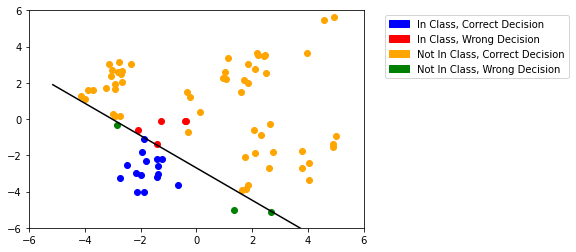

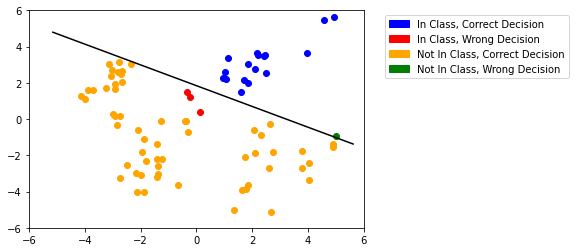

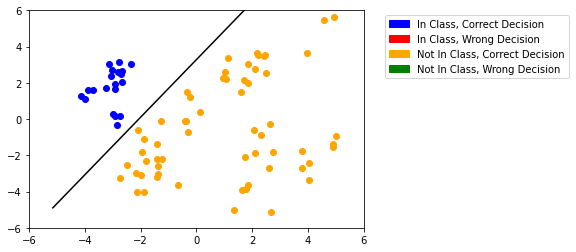

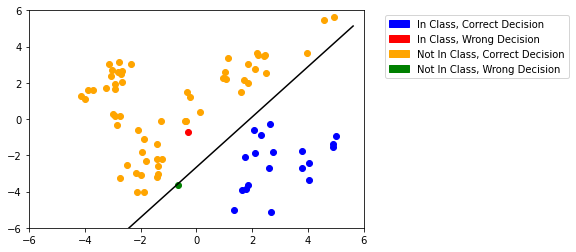

In [8]:
#Plotting
for k in np.unique(y):
    fig, ax = plt.subplots()
    ax.set(xlim = (-6, 6), ylim = (-6, 6))
    y_split = np.where(y == k, 1, -1) #Check location of given class, mark with present or not present. 
    for i, j in enumerate(x):
        temp = np.matmul(np.transpose(w_collection[k]), x[i]) #Returns value of w^Tx. 
        if(temp > 0 and y_split[i] == 1): #In Class, Correct Decision
            ax.scatter(x[i][1], x[i][2], c='blue') #No need to include first element as it is all 1. 
        elif(temp < 0 and y_split[i] == 1): #In Class, Wrong Decision
            ax.scatter(x[i][1], x[i][2], c='red') 
        elif(temp < 0 and y_split[i] == -1): #Not In Class, Correct Decision
            ax.scatter(x[i][1], x[i][2], c='orange') 
        else: #Not In Class, Wrong Decision. 
            ax.scatter(x[i][1], x[i][2], c='green') 
    x_plot = [np.amin(x[:,:]), np.amax(x[:,:])] #Min and max values of dataset. 
    w = w_collection[k]
    m = -(w[0]/w[2])/(w[0]/w[1]) #Slope
    b = -w[0]/w[2] #y-intercept
    y_plot = [m * np.amin(x[:,:]) + b, m * np.amax(x[:,:]) + b] #y = mx + b
    ax.plot(x_plot, y_plot, c='black') #Plotting line. 
    red_circle = mpatches.Patch(color='red', label='In Class, Wrong Decision')
    blue_circle = mpatches.Patch(color='blue', label='In Class, Correct Decision')
    green_circle = mpatches.Patch(color='green', label='Not In Class, Wrong Decision')
    orange_circle = mpatches.Patch(color='orange', label='Not In Class, Correct Decision')
    plt.legend(bbox_to_anchor=(1.05, 1.0), handles = [blue_circle, red_circle, orange_circle, green_circle]) #For ease of reading.
    plt.show() 

In [9]:
N_mistakes = 0
for i, j in enumerate(y):
    if(y[i] != y_pred[i]):
        N_mistakes += 1
print('Number of Mistakes: ' + str(N_mistakes))
print('Error Rate: ' + str(N_mistakes / y.size)) #N_mistakes divided by number of elements.

Number of Mistakes: 1
Error Rate: 0.0125


In [10]:
#Part 2: One-Versus-One.
#Using Logistic Regression to get multiple w values.

In [11]:
#Acquire all w for each pair of labels in y
start_time = time.time()
pairs = [(a, b) for idx, a in enumerate(np.unique(y)) for b in np.unique(y)[idx + 1:]] #Get all unique pairs.
w_collection = dict.fromkeys(pairs, [])
for i, j in pairs: 
    index = np.where(np.where((y == i) | (y == j), 1, -1) == 1)
    x_split = x[index] #Values where x corresponds to y
    y_split = np.where(y[index] == i, 1, -1) #Values where y = i or j, set to 1, -1 respectively. 
    w_collection[i, j] = (logreg(x_split, y_split, np.zeros(len(x[0])), 0.1, 0.01)) #logreg function defined above.
print(time.time() - start_time)
w_collection

2.795532464981079


{(1.0, 2.0): array([ 0.36697201, -1.91163105, -2.70790394]),
 (1.0, 3.0): array([ 2.75245146,  1.74818255, -3.55302981]),
 (1.0, 4.0): array([ 1.77593086e-01, -2.80706968e+00, -8.17937186e-04]),
 (2.0, 3.0): array([1.39910382, 3.0409981 , 0.92898301]),
 (2.0, 4.0): array([ 0.18518326, -0.8054489 ,  3.00475266]),
 (3.0, 4.0): array([-0.46770494, -1.61775823,  1.27242788])}

In [12]:
#Soft Voting
y_pred = np.zeros(len(y))
index = -1
for i in x:
    index += 1
    votes = dict.fromkeys(np.unique(y), 0) #Dictionary holding counts of predictions of class. 
    for j, k in w_collection:
        temp = np.matmul(np.transpose(w_collection[j, k]), i) #w^Tx
        if(temp > 0):
            votes[j] += 1
        else:
            votes[k] += 1
    keyList = list() #Checking length at the end. 
    max_val = max(votes, key = lambda a: votes[a]) #Maximum Value. 
    for key, value in votes.items():
        if value == max_val:
            keyList.append(key)
    if(len(keyList) > 1):
        y_pred[index] = 0 #Multiple maximum values -> inconclusive. 
    else:
        y_pred[index] = max_val #Else, set prediction to most votes. 
y_pred

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2., 2.,
       2., 2., 2., 2., 2., 2., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3., 3.,
       3., 3., 3., 3., 3., 3., 3., 3., 3., 1., 4., 4., 4., 4., 4., 4., 4.,
       4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4., 4.])

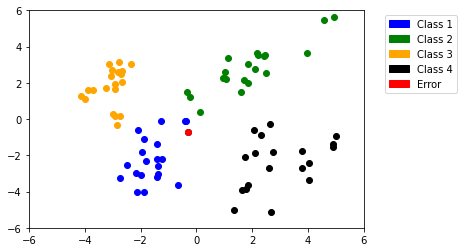

In [13]:
#Plotting
fig, ax = plt.subplots()
ax.set(xlim = (-6, 6), ylim = (-6, 6))
for i, j in enumerate(x): #Plotting different classes. 
    if(y[i] == 1): 
        ax.scatter(x[i][1], x[i][2], c='blue') 
    elif(y[i] == 2): 
        ax.scatter(x[i][1], x[i][2], c='green') 
    elif(y[i] == 3): 
        ax.scatter(x[i][1], x[i][2], c='orange') 
    else:  
        ax.scatter(x[i][1], x[i][2], c='black')
for i, j in enumerate(x):
    if(y[i] != y_pred[i]):
        ax.scatter(x[i][1], x[i][2], c='red') #Color misaligned point red.
blue_circle = mpatches.Patch(color='blue', label='Class 1')
green_circle = mpatches.Patch(color='green', label='Class 2')
orange_circle = mpatches.Patch(color='orange', label='Class 3')
black_circle = mpatches.Patch(color='black', label='Class 4')
red_circle = mpatches.Patch(color='red', label='Error')
plt.legend(bbox_to_anchor=(1.05, 1.0), handles = [blue_circle, green_circle, orange_circle, black_circle, red_circle]) #For ease of reading.
plt.show()

In [14]:
N_mistakes = 0
for i, j in enumerate(y):
    if(y[i] != y_pred[i]):
        N_mistakes += 1
print('Number of Mistakes: ' + str(N_mistakes))
print('Error Rate: ' + str(N_mistakes / y.size)) #N_mistakes divided by number of elements.

Number of Mistakes: 1
Error Rate: 0.0125
